# Step 5: Virtual Screening

Apply the trained model to score a library of novel compounds,
rank by predicted binding affinity, and filter by drug-likeness.

In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, Draw, Lipinski
from rdkit import DataStructs
from PIL import Image
from io import BytesIO
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

best_model = joblib.load('../models/best_model.pkl')
metadata = joblib.load('../models/metadata.pkl')
scaler = joblib.load('../models/scaler.pkl')

print(f"Model: {metadata['best_model']}")
print(f"Test R\u00b2: {metadata['best_r2']:.4f}")
print(f"Expected features: {metadata['n_features']}")

Model: XGBoost
Test R²: 0.7357
Expected features: 2060


## 5.1 Screening Library

In [2]:
screening_smiles = [
    'C1=CC=C2C(=C1)C=NC(=N2)NC3=CC=CC=C3',
    'COC1=CC2=C(C=C1)N=CN=C2NC3=CC(=CC=C3)Cl',
    'C1=CC(=CC=C1NC2=NC=NC3=CC=CC=C32)O',
    'COC1=CC=CC=C1NC2=NC=NC3=CC(=CC=C32)OC',
    'C1=CC=C(C=C1)NC2=NC=NC3=CC(=CC=C32)NC(=O)C4=CC=CS4',
    'CC1=CN=C(N=C1N)C2=CC=NC=C2',
    'C1=CC(=CC=C1C2=NC(=NC=C2)N)F',
    'CC(C)NC1=NC=NC2=CC=C(C=C12)OC3=CC=CC=C3',
    'COC1=CC=C(C=C1)C2=NC(=NC=C2)NCC3=CC=CO3',
    'C1=CC=C(C=C1)C(=O)NC2=CC=C(C=C2)C3=NC=NC=C3N',
    'C1=CC2=C(C=C1F)C(=CN2)C3=CC=NC=C3',
    'CC1=CC2=C(N1)C=CC(=C2)NC(=O)C3=CC=CC=C3F',
    'C1=CC=C2C(=C1)C=C(N2)C(=O)NC3=CC=C(C=C3)Cl',
    'COC1=CC2=C(C=C1)NC(=C2)C3=CC=CC=C3O',
    'C1=CC=C(C=C1)NC(=O)C2=CC3=CC=CC=C3N2',
    'C1=CC=C2C(=C1)NC(=N2)C3=CC=C(C=C3)O',
    'CC1=NC2=CC=CC=C2N1CC(=O)NC3=CC=CC=C3',
    'C1=CC(=CC=C1NC(=O)CN2C=NC3=CC=CC=C32)Cl',
    'COC1=CC=CC=C1C2=NC3=CC=CC=C3N2CC#N',
    'C1=CC=C2C(=C1)N=C(N2CCNC(=O)C3=CC=CS3)C4=CC=CC=C4',
    'CC1=NN(C(=C1)C2=CC=CC=C2F)C3=CC=CC=C3',
    'C1=CC(=CC=C1C2=CC(=NN2C3=CC=CC=C3)C(F)(F)F)O',
    'CC1=NN(C(=C1)C(=O)NC2=CC=C(C=C2)F)C',
    'C1=CC=C(C=C1)C2=NN(C(=C2)CO)CC3=CC=CO3',
    'CC(=O)NC1=CC=C(C=C1)C2=CC(=NN2C)C3=CC=CS3',
    'C1=CC=C(C=C1)CCNC(=O)C2=CC=NC=C2',
    'COC1=CC=C(C=C1)C(=O)NC2=CC3=CC=CC=C3N2',
    'C1=CC(=CC=C1NC(=O)C2=CC=C(C=C2)CN3CCCC3)F',
    'CC(C)NC(=O)C1=CC=C(C=C1)OC2=CC=CC=C2',
    'C1=CC=C2C(=C1)OC(=N2)NC3=CC=C(C=C3)S(=O)(=O)N',
    'O=C(NC1=CC=CC=C1)C2=CC=C(O2)C3=CC=NC=C3',
    'CC1=CC(=NO1)C2=CC=C(C=C2)NC(=O)CC3=CC=CS3',
    'C1=CN=C(C=C1)C2=CC=C(O2)C(=O)NC3=CC=CC=C3F',
    'COC1=CC(=CC=C1)C(=O)NC2=CC=C3C(=C2)N=CN3C',
    'CC1=CC=C(C=C1)S(=O)(=O)NC2=CC=CC=C2C(=O)O',
    'C1=CC(=CC=C1OCCNC2=NC=NC=C2)Cl',
    'CC(C)(C)C1=CC=C(C=C1)NC(=O)C2=CC=NC3=CC=CC=C23',
    'C1=CC=C(C=C1)C2=CC3=CC=CC=C3OC2=O',
    'COC1=CC=CC(=C1)C(=O)NC2=CC=C(C=C2)C3=CC=NN3C',
    'C1=CC=C2C(=C1)C(=O)N(C2=O)CC3=CC=C(C=C3)NC(=O)C4CC4'
]
print(f"Screening library: {len(screening_smiles)} compounds")

Screening library: 40 compounds


## 5.2 Compute Features

In [3]:
def compute_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    desc = {
        'MW': Descriptors.MolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'HBA': Descriptors.NumHAcceptors(mol),
        'HBD': Descriptors.NumHDonors(mol),
        'TPSA': Descriptors.TPSA(mol),
        'RotBonds': Descriptors.NumRotatableBonds(mol),
        'AromaticRings': Descriptors.NumAromaticRings(mol),
        'HeavyAtoms': Descriptors.HeavyAtomCount(mol),
        'RingCount': Descriptors.RingCount(mol),
        'FractionCSP3': Descriptors.FractionCSP3(mol),
        'NumHeteroatoms': Descriptors.NumHeteroatoms(mol),
        'MolRefractivity': Descriptors.MolMR(mol),
    }
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
    fp_arr = np.zeros(2048, dtype=int)
    DataStructs.ConvertToNumpyArray(fp, fp_arr)
    for i in range(2048):
        desc[f'FP_{i}'] = fp_arr[i]
    return desc

screen_features, valid_smiles = [], []
for smi in screening_smiles:
    feat = compute_features(smi)
    if feat is not None:
        screen_features.append(feat)
        valid_smiles.append(smi)

screen_X = pd.DataFrame(screen_features)
print(f"Valid compounds: {len(screen_X)}, Features: {screen_X.shape[1]}")

Valid compounds: 40, Features: 2060


[23:56:19] DEPRECATION WARNING: please use MorganGenerator
[23:56:19] DEPRECATION WARNING: please use MorganGenerator
[23:56:19] DEPRECATION WARNING: please use MorganGenerator
[23:56:19] DEPRECATION WARNING: please use MorganGenerator
[23:56:19] DEPRECATION WARNING: please use MorganGenerator
[23:56:19] DEPRECATION WARNING: please use MorganGenerator
[23:56:19] DEPRECATION WARNING: please use MorganGenerator
[23:56:19] DEPRECATION WARNING: please use MorganGenerator
[23:56:19] DEPRECATION WARNING: please use MorganGenerator
[23:56:19] DEPRECATION WARNING: please use MorganGenerator
[23:56:19] DEPRECATION WARNING: please use MorganGenerator
[23:56:19] DEPRECATION WARNING: please use MorganGenerator
[23:56:19] DEPRECATION WARNING: please use MorganGenerator
[23:56:19] DEPRECATION WARNING: please use MorganGenerator
[23:56:19] DEPRECATION WARNING: please use MorganGenerator
[23:56:19] DEPRECATION WARNING: please use MorganGenerator
[23:56:19] DEPRECATION WARNING: please use MorganGenerat

## 5.3 Predict Binding Affinities

In [4]:
if metadata['needs_scaling']:
    predictions = best_model.predict(scaler.transform(screen_X))
else:
    predictions = best_model.predict(screen_X)

results = pd.DataFrame({
    'SMILES': valid_smiles,
    'Predicted_pChEMBL': predictions,
    'MW': screen_X['MW'].values,
    'LogP': screen_X['LogP'].values,
    'HBA': screen_X['HBA'].values,
    'HBD': screen_X['HBD'].values,
    'TPSA': screen_X['TPSA'].values,
    'RotBonds': screen_X['RotBonds'].values
})
results = results.sort_values('Predicted_pChEMBL', ascending=False).reset_index(drop=True)
print(f"Predicted pChEMBL range: [{predictions.min():.2f}, {predictions.max():.2f}]")
results.head(10)

Predicted pChEMBL range: [4.45, 7.53]


,SMILES,Predicted_pChEMBL,MW,LogP,HBA,HBD,TPSA,RotBonds
0,COC1=CC2=C(C=C1)N=CN=C2NC3=CC(=CC=C3)Cl,7.526527,285.734,4.03540,4,1,47.04,3
1,C1=CC=C(C=C1)NC2=NC=NC3=CC(=CC=C32)NC(=O)C4=CC...,6.786363,346.415,4.68720,5,2,66.91,4
2,CC(C)NC1=NC=NC2=CC=C(C=C12)OC3=CC=CC=C3,6.594976,279.343,4.24240,4,1,47.04,4
3,COC1=CC=CC=C1NC2=NC=NC3=CC(=CC=C32)OC,6.528180,281.315,3.39060,5,1,56.27,4
4,C1=CC(=CC=C1C2=NC(=NC=C2)N)F,6.465213,189.193,1.86490,3,1,51.80,1
5,C1=CC(=CC=C1NC2=NC=NC3=CC=CC=C32)O,6.439677,237.262,3.07900,4,2,58.04,2
6,CC1=CN=C(N=C1N)C2=CC=NC=C2,6.264833,186.218,1.42922,4,1,64.69,1
7,C1=CC(=CC=C1OCCNC2=NC=NC=C2)Cl,6.218314,249.701,2.62090,4,1,47.04,5
8,C1=CC=C2C(=C1)N=C(N2CCNC(=O)C3=CC=CS3)C4=CC=CC=C4,6.115471,347.443,4.19480,3,1,46.92,5
9,C1=CC=C2C(=C1)C(=O)N(C2=O)CC3=CC=C(C=C3)NC(=O)...,5.955432,320.348,2.83130,3,1,66.48,4


## 5.4 Lipinski Rule of 5 Filtering

In [5]:
def check_lipinski(row):
    violations = 0
    if row['MW'] > 500: violations += 1
    if row['LogP'] > 5: violations += 1
    if row['HBA'] > 10: violations += 1
    if row['HBD'] > 5: violations += 1
    return violations

results['Lipinski_Violations'] = results.apply(check_lipinski, axis=1)
results['Drug_Like'] = results['Lipinski_Violations'] <= 1

drug_like = results[results['Drug_Like']]
print(f"Drug-like compounds: {len(drug_like)}/{len(results)}")
drug_like.head(20)

Drug-like compounds: 40/40


,SMILES,Predicted_pChEMBL,MW,LogP,HBA,HBD,TPSA,RotBonds,Lipinski_Violations,Drug_Like
0,COC1=CC2=C(C=C1)N=CN=C2NC3=CC(=CC=C3)Cl,7.526527,285.734,4.03540,4,1,47.04,3,0,True
1,C1=CC=C(C=C1)NC2=NC=NC3=CC(=CC=C32)NC(=O)C4=CC...,6.786363,346.415,4.68720,5,2,66.91,4,0,True
2,CC(C)NC1=NC=NC2=CC=C(C=C12)OC3=CC=CC=C3,6.594976,279.343,4.24240,4,1,47.04,4,0,True
3,COC1=CC=CC=C1NC2=NC=NC3=CC(=CC=C32)OC,6.528180,281.315,3.39060,5,1,56.27,4,0,True
4,C1=CC(=CC=C1C2=NC(=NC=C2)N)F,6.465213,189.193,1.86490,3,1,51.80,1,0,True
5,C1=CC(=CC=C1NC2=NC=NC3=CC=CC=C32)O,6.439677,237.262,3.07900,4,2,58.04,2,0,True
6,CC1=CN=C(N=C1N)C2=CC=NC=C2,6.264833,186.218,1.42922,4,1,64.69,1,0,True
7,C1=CC(=CC=C1OCCNC2=NC=NC=C2)Cl,6.218314,249.701,2.62090,4,1,47.04,5,0,True
8,C1=CC=C2C(=C1)N=C(N2CCNC(=O)C3=CC=CS3)C4=CC=CC=C4,6.115471,347.443,4.19480,3,1,46.92,5,0,True
9,C1=CC=C2C(=C1)C(=O)N(C2=O)CC3=CC=C(C=C3)NC(=O)...,5.955432,320.348,2.83130,3,1,66.48,4,0,True


## 5.5 Visualize Results

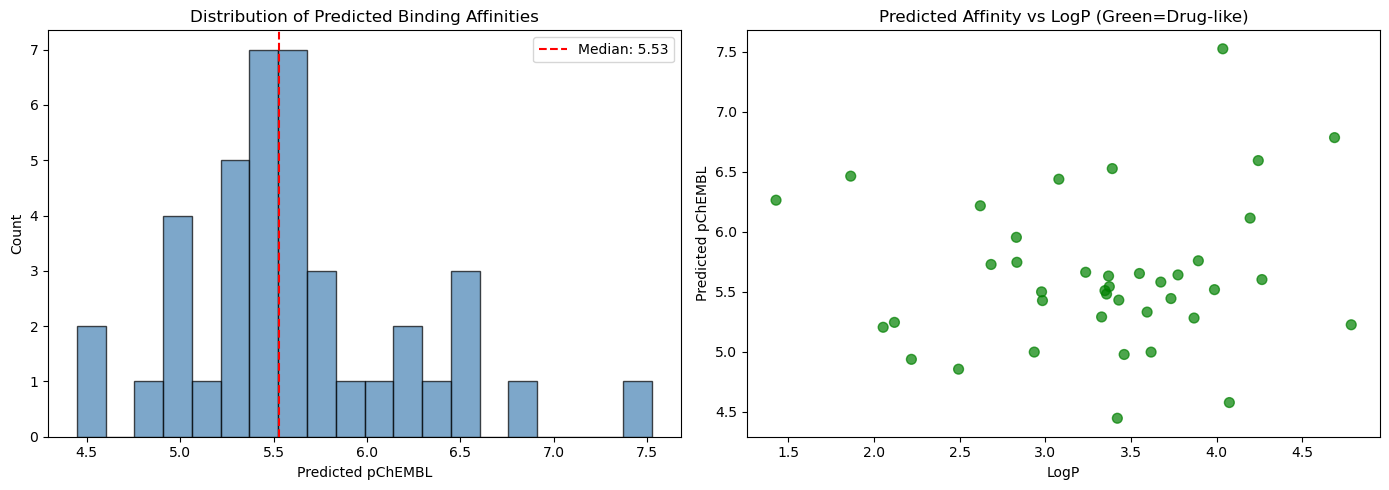

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(results['Predicted_pChEMBL'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Predicted pChEMBL')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Predicted Binding Affinities')
axes[0].axvline(results['Predicted_pChEMBL'].median(), color='red', linestyle='--',
               label=f"Median: {results['Predicted_pChEMBL'].median():.2f}")
axes[0].legend()

colors = ['green' if dl else 'red' for dl in results['Drug_Like']]
axes[1].scatter(results['LogP'], results['Predicted_pChEMBL'], c=colors, alpha=0.7, s=50)
axes[1].set_xlabel('LogP')
axes[1].set_ylabel('Predicted pChEMBL')
axes[1].set_title('Predicted Affinity vs LogP (Green=Drug-like)')

plt.tight_layout()
plt.savefig('../models/virtual_screening_results.png', dpi=150, bbox_inches='tight')
plt.show()

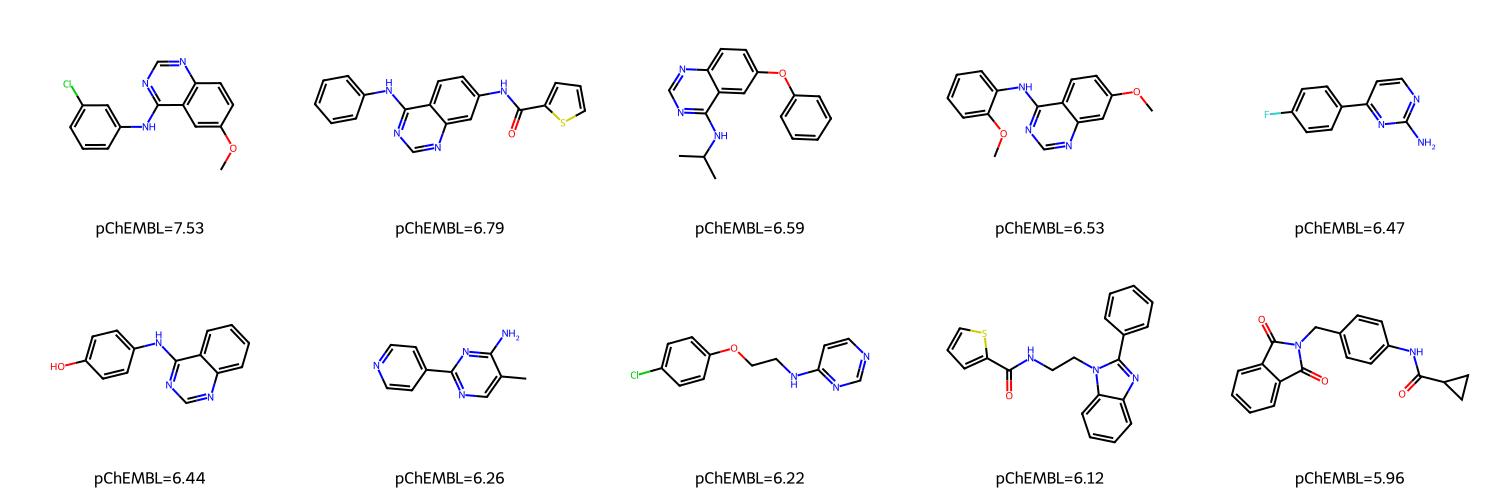

In [7]:
# Draw top 10 molecules
top_mols = [Chem.MolFromSmiles(smi) for smi in drug_like['SMILES'].head(10)]
top_legends = [f"pChEMBL={row['Predicted_pChEMBL']:.2f}" 
               for _, row in drug_like.head(10).iterrows()]

grid_img = Draw.MolsToGridImage(top_mols, molsPerRow=5, subImgSize=(300, 250), legends=top_legends)

# Save - handle both PIL Image and IPython Image
if isinstance(grid_img, Image.Image):
    grid_img.save('../models/top_candidates.png')
else:
    pil_img = Image.open(BytesIO(grid_img.data))
    pil_img.save('../models/top_candidates.png')

grid_img

In [8]:
results.to_csv('../data/processed/screening_results.csv', index=False)
drug_like.to_csv('../data/processed/top_candidates.csv', index=False)

print(f"Virtual Screening Summary:")
print(f"  Total screened: {len(results)}")
print(f"  Drug-like candidates: {len(drug_like)}")
print(f"  Top predicted pChEMBL: {results['Predicted_pChEMBL'].max():.2f}")

Virtual Screening Summary:
  Total screened: 40
  Drug-like candidates: 40
  Top predicted pChEMBL: 7.53
